In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.insert(0, "../func_py/")
import infer_memplasm as mp
import data_utils as dtu

In [2]:
# Auxiliary functions

def marginalize(filtered_fr, field, agg_label, norm=True):
    aggr = filtered_fr.groupby(field).agg({agg_label : "sum"})
    ns, ps = aggr.index.values, aggr[agg_label].values
    if norm: ps = ps / ps.sum()
    return ns, ps


def fill_tuple(fr, labels, max_n_per_label):
    prod_set = []
    for max_n in max_n_per_label:
        prod_set.append( np.arange(int(max_n)) )

    for ns in mp.product(*prod_set):
        _id = ""
        for i, n in enumerate(ns):
            _id += str(n) + "_"
        _id = _id[:-1]

        if _id not in fr.index:
            for i, si in enumerate(labels):
                fr.loc[_id, si] = ns[i]
    return fr

def make_count_profile(sp_counts, field, agg_label, bins=8, density=True):
    
    delta_ser = sp_counts.groupby(field).agg({agg_label : "sum"})
    delta_uni, delta_counts = delta_ser.index.values, delta_ser[agg_label].values

    if type(bins) == int:
        bins_mid = np.linspace(min(delta_uni), max(delta_uni), bins)
        dbin = bins_mid[1] - bins_mid[0]
        bins = np.append(bins_mid - 0.5*dbin, bins_mid[-1] + 0.5*dbin)
    else:
        bins_mid = (bins[1:] + bins[:-1]) / 2.0
        dbin = bins_mid[1] - bins_mid[0]
    
    bin_counts = np.zeros(len(bins_mid))
    for i in range(len(bins_mid)):
        mask = np.logical_and(delta_uni > bins[i], delta_uni <= bins[i+1])
        bin_counts[i] = delta_counts[mask].sum()
        
    if density:
        bin_counts = bin_counts / bin_counts.sum() / dbin
    
    return bins_mid, bin_counts


def sample_and_bin(sp_counts, tau_p, theta_p, mp_pars):
    
    Mms = [np.sum(sp_counts['counts_m'+str(i+1)]*sp_counts['occ']) for i in mp_pars.m_indexes]
    Mps = [np.sum(sp_counts['counts_p'+str(i+1)]*sp_counts['occ']) for i in mp_pars.p_indexes]
    n_max = max(sp_counts.counts_m1.values)
    import_f = mp.get_gamma_prior(n_max, Mms[0], mp_pars.Mm_tot, mp_pars.prior_pars[0], mp_pars.prior_pars[1])
    xs, ys = mp.sample(tau_p, theta_p, mp_pars, import_f)
    
    xs_bins, ys_bins, x_vals, y_vals = mp.discretize_logcounts(xs, ys, 10000)
    auxp1 = np.append(0, mp.stat_dist(x_vals, mp_pars) / import_f.pdf(x_vals))
    m_vals = np.exp(x_vals)
    m_mus, p_mus = [], [] # Averages of the noise model for memory and plasmablasts
    for i in range(len(mp_pars.m_indexes)): 
        m_mus.append( np.append(0, m_vals * Mms[i] / mp_pars.Mm_tot) )
    Mp_cells = mp_pars.Mm_tot * mp_pars.p_to_m
    p_vals = np.exp(y_vals)
    for i in range(len(mp_pars.p_indexes)): 
        p_mus.append( np.append(0, p_vals * Mps[i] / Mp_cells) ) 
        
    return auxp1, m_mus, p_mus, xs_bins, ys_bins, xs, ys


label_to_index = {'m1':0, 'm2':1, 'm3':2, 'p2':3, 'p3':4}


def build_pair_frame(sp_counts, labels, max_n):
    ids = [label_to_index[l] for l in labels]
    ns = sp_counts.index.str.split('_').str[ids[0]]
    for i in ids[1:]:
        ns += '_' + sp_counts.index.str.split('_').str[i]
    uni_ns = np.unique(ns)
    probs = pd.DataFrame(index=uni_ns)
    for k, l in enumerate(labels):
        probs[l] = np.array(probs.index.str.split('_').str[k], dtype=int)
    return fill_tuple(probs, labels, np.ones(len(labels))*max_n)

In [3]:
# Importing the results and setting the parameters

m_der_f = 0.5
p_to_m = 0.05

pat = '2'
mem_samp = ['pat2_t1_mc', 'pat2_t2_mc', 'pat2_t3_mc']
pb_samp = ['', 'pat2_t2_pc', 'pat2_t3_pc']
sp_counts, pars = mp.import_data(mem_samp, pb_samp)
dtimes, dts = [6, 1/6], [0.1, 0.01]
file_name = 'pat2_3_exe'
gbm_pars = dtu.read_pars('inference/gbm/' + file_name + '.txt')
result_fr = pd.read_csv('inference/memplasm/result_pat'+pat+'.csv', index_col=0)
best_pars = result_fr[np.logical_and(result_fr.m_der_f==m_der_f, result_fr.p_to_m==p_to_m)].iloc[0]
tau_p = 10**best_pars['log10_tau_p']
theta_p = 10**best_pars['log10_theta_p']

mp_pars = mp.mp_infer_pars(
    dtimes=dtimes, sample_indexes=[pars['m_ids'], pars['p_ids']],
    tau_m=gbm_pars['tau'], theta_m=gbm_pars['theta'], Mm_tot=gbm_pars['M_tot'], n0=gbm_pars['n0'],
    m_der_f=m_der_f, p_to_m=p_to_m, 
    n_eval=int(1*10**6), prior_pars=[5,4], dts=dts, n1_min=0
)

count_labels = ['m2', 'm3', 'p2', 'p3']
log_zero_val = -1
for lab in count_labels:
    cs = sp_counts['counts_'+lab]
    sp_counts['logc_'+lab] = np.where(cs>0, np.log(cs, where=cs.values>0), log_zero_val)
    
sp_counts['delta_logc_p'] = sp_counts['logc_p3'] - sp_counts['logc_p2']
sp_counts['delta_p'] = sp_counts['counts_p3'] - sp_counts['counts_p2']

### Marginal of number of counts at time 2 (may 2020) of patient 2
To reach large values of p2 we just generate two time points

In [4]:
def compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, label, max_n):
    
    auxp1, m_mus, p_mus, xs_bins, ys_bins, xs, ys  = sample_and_bin(sp_counts, tau_p, theta_p, mp_pars)
    probs = build_pair_frame(sp_counts, ['m1', label], max_n)
    sp_index = label_to_index[label] - 3
    
    for _id, row in probs.iterrows():
        poiss_m1 = (mp.poisson(m_mus[0]).pmf(row.m1) * auxp1)[xs_bins[0][:mp_pars.n_eval]]
        poiss_p = mp.poisson(p_mus[sp_index]).pmf(row[label])[ys_bins[sp_index+1][:mp_pars.n_eval]]
        weight = np.sum(poiss_m1 * poiss_p)
        if row.m1 == 0:
            poiss_p_new = mp.poisson(p_mus[sp_index]).pmf(row[label])[ys_bins[sp_index+1][mp_pars.n_eval:]]
            weight_new = np.sum(poiss_p_new)
        else:
            weight_new = 0

        probs.loc[_id, 'p'] = (weight + weight_new) / len(xs_bins[0])
    return probs

%time probs_p2 = compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, 'p2', 30)
mask = sp_counts.counts_m1 > 0
ks2, p_k2 = marginalize(sp_counts[mask], 'counts_p2', 'occ')
k2s_th, p_k2_th = marginalize(probs_p2[probs_p2.m1 > 0], 'p2', 'p')

CPU times: user 11.1 s, sys: 133 ms, total: 11.2 s
Wall time: 11.2 s


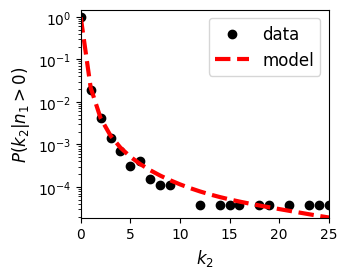

In [5]:
plt.figure(figsize=(3.2, 2.7))
plt.yscale('log')
plt.ylabel(r"$P(k_2 | n_1 > 0)$", fontsize=12)
plt.xlabel(r"$k_2$", fontsize=12)
plt.xlim(np.min(ks2)*0.9, 25)
plt.ylim(np.min(p_k2)*0.5, np.max(p_k2)*1.5)

plt.scatter(ks2, p_k2, c='k', label='data')
plt.plot(k2s_th, p_k2_th, c='r', lw=3, ls='--', label='model')
plt.legend(fontsize=12)

### Marginal of number of counts at time 3 (July 2020) of patient 2

In [6]:
%time probs_p3 = compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, 'p3', 30)
mask = sp_counts.counts_m1 > 0
ks3, p_k3 = marginalize(sp_counts[mask], 'counts_p3', 'occ')
k3s_th, p_k3_th = marginalize(probs_p3[probs_p3.m1 > 0], 'p3', 'p')

CPU times: user 11 s, sys: 105 ms, total: 11.1 s
Wall time: 11.2 s


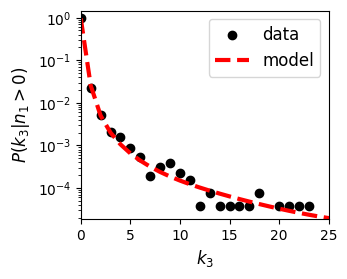

In [7]:
plt.figure(figsize=(3.2, 2.7))
plt.yscale('log')
plt.ylabel(r"$P(k_3 | n_1 > 0)$", fontsize=12)
plt.xlabel(r"$k_3$", fontsize=12)
plt.xlim(np.min(ks3)*0.9, 25)
plt.ylim(np.min(p_k3)*0.5, np.max(p_k3)*1.5)

plt.scatter(ks3, p_k3, c='k', label='data')
plt.plot(k3s_th, p_k3_th, c='r', lw=3, ls='--', label='model')
plt.legend(fontsize=12)

### Delta counts between time 3 and two of plasmablast clones

In [15]:
def compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, max_n):
    
    auxp1, m_mus, p_mus, xs_bins, ys_bins, xs, ys = sample_and_bin(sp_counts, tau_p, theta_p, mp_pars)
    probs = build_pair_frame(sp_counts, ['m1', 'p2', 'p3'], max_n)
    
    for _id, row in probs.iterrows():
        poiss_m1 = (mp.poisson(m_mus[0]).pmf(row.m1) * auxp1)[xs_bins[0][:mp_pars.n_eval]]
        poiss_p2 = mp.poisson(p_mus[0]).pmf(row.p2)[ys_bins[1][:mp_pars.n_eval]]
        poiss_p3 = mp.poisson(p_mus[1]).pmf(row.p3)[ys_bins[2][:mp_pars.n_eval]]
        weight = np.sum(poiss_m1 * poiss_p2 * poiss_p3)
        if row.m1 == 0:
            poiss_p2_new = mp.poisson(p_mus[0]).pmf(row.p2)[ys_bins[1][mp_pars.n_eval:]]
            poiss_p3_new = mp.poisson(p_mus[1]).pmf(row.p3)[ys_bins[2][mp_pars.n_eval:]]
            weight_new = np.sum(poiss_p2_new * poiss_p3_new)
        else:
            weight_new = 0

        probs.loc[_id, 'p'] = (weight + weight_new) / len(xs_bins[0])
    return probs

%time probs_deltap = compute_p_marg(sp_counts, 0.4, 0.06, mp_pars, 20)
count_labels = ['p2', 'p3']
log_zero_val = -1
for lab in count_labels:
    cs = probs_deltap[lab]
    probs_deltap['logc_'+lab] = np.where(cs>0, np.log(cs, where=cs.values>0), log_zero_val)
mask = sp_counts.counts_m1 > 0
gp = sp_counts[mask].groupby('delta_p').agg({'occ' : "sum"})
mask = probs_deltap.m1 > 0
probs_deltap['delta_p'] = probs_deltap['p3'] - probs_deltap['p2']
gp_th = probs_deltap[mask].groupby('delta_p').agg({'p' : "sum"})

CPU times: user 1min 43s, sys: 154 ms, total: 1min 44s
Wall time: 1min 44s


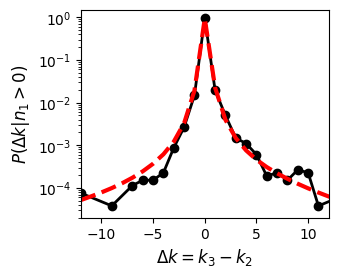

In [16]:
plt.figure(figsize=(3.2, 2.7))
plt.yscale('log')
plt.ylabel(r"$P(\Delta k | n_1 > 0)$", fontsize=12)
plt.xlabel(r"$\Delta k = k_3 - k_2$", fontsize=12)
plt.xlim(-12,12)
plt.ylim(2*10**(-5), 1.5)

plt.scatter(gp.index.values, gp.occ.values / gp.occ.sum(), c='k')
plt.plot(gp.index.values, gp.occ.values / gp.occ.sum(),  c='k', lw=2)

plt.plot(gp_th.index.values, gp_th.p.values / gp_th.p.sum(), c='r', ls='--', lw=3)

### Marginals conditioned on memory-cell counts and plasmablast counts
We also study how the probability of observing a $\Delta k$ changes dependening on the sign of $\Delta n$.

In [17]:
def compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, max_n):
    
    auxp1, m_mus, p_mus, xs_bins, ys_bins, xs, ys = sample_and_bin(sp_counts, tau_p, theta_p, mp_pars)
    probs = build_pair_frame(sp_counts, ['m1', 'm2', 'm3', 'p2', 'p3'], max_n)
    
    poiss_m1s = {m1 : mp.poisson(m_mus[0]).pmf(m1) * auxp1 for m1 in np.unique(probs['m1'])}
    poiss_m2s = {m2 : mp.poisson(m_mus[1]).pmf(m2) for m2 in np.unique(probs['m2'])}
    poiss_m3s = {m3 : mp.poisson(m_mus[2]).pmf(m3) for m3 in np.unique(probs['m3'])}
    poiss_p2s = {p2 : mp.poisson(p_mus[0]).pmf(p2) for p2 in np.unique(probs['p2'])}
    poiss_p3s = {p3 : mp.poisson(p_mus[1]).pmf(p3) for p3 in np.unique(probs['p3'])}
        
    for _id, row in probs.iterrows():
        
        if row.p2 + row.p3 == 0: continue
        if row.m2 + row.m3 == 0: continue
            
        poiss_m1 = poiss_m1s[row.m1][xs_bins[0][:mp_pars.n_eval]]
        poiss_m2 = poiss_m2s[row.m2][xs_bins[1][:mp_pars.n_eval]]
        poiss_m3 = poiss_m3s[row.m3][xs_bins[2][:mp_pars.n_eval]]
        poiss_p2 = poiss_p2s[row.p2][ys_bins[1][:mp_pars.n_eval]]
        poiss_p3 = poiss_p3s[row.p3][ys_bins[2][:mp_pars.n_eval]]
        weight = np.sum(poiss_m1 * poiss_m2 * poiss_m3 * poiss_p2 * poiss_p3)
        if row.m1 == 0:
            poiss_m2_new = poiss_m2s[row.m2][ys_bins[1][mp_pars.n_eval:]]
            poiss_m3_new = poiss_m3s[row.m3][ys_bins[2][mp_pars.n_eval:]]
            poiss_p2_new = poiss_p2s[row.p2][ys_bins[1][mp_pars.n_eval:]]
            poiss_p3_new = poiss_p3s[row.p3][ys_bins[2][mp_pars.n_eval:]]
            weight_new = np.sum(poiss_m2_new * poiss_m3_new * poiss_p2_new * poiss_p3_new)
        else:
            weight_new = 0

        probs.loc[_id, 'p'] = (weight + weight_new) / len(xs[0])
    return probs

%time probs = compute_p_marg(sp_counts, tau_p, theta_p, mp_pars, 11)

mask = np.logical_and(sp_counts.counts_m2 > 1,  sp_counts.counts_m3 > 1)
mask = np.logical_and(mask,  sp_counts.counts_p2 > 1)
ns1, p_ns1 = marginalize(sp_counts[mask], 'counts_p3', 'occ')
mask = np.logical_and(sp_counts.counts_m2 < 2,  sp_counts.counts_m3 < 2)
mask = np.logical_and(sp_counts.counts_m2 + sp_counts.counts_m3 > 0, mask)
mask = np.logical_and(mask,  sp_counts.counts_p2 < 2)
mask = np.logical_and(mask,  sp_counts.counts_p2 + sp_counts.counts_p3 > 0)
ns2, p_ns2 = marginalize(sp_counts[mask], 'counts_p3', 'occ')

mask = np.logical_and(probs.m2 > 1, probs.m3 > 1)
mask = np.logical_and(mask,  probs.p2 > 1)
ns1_th, p_ns1_th = marginalize(probs[mask], 'p3', 'p')
mask = np.logical_and(probs.m2 < 2,  probs.m3 < 2)
mask = np.logical_and(probs.m2 + probs.m3 > 0, mask)
mask = np.logical_and(mask,  probs.p2 < 2)
ns2_th, p_ns2_th = marginalize(probs[mask], 'p3', 'p')

CPU times: user 57min 47s, sys: 1.03 s, total: 57min 48s
Wall time: 57min 49s


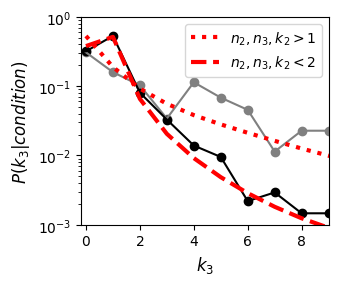

In [18]:
plt.figure(figsize=(3.2, 2.7))
plt.ylabel(r"$P(k_3 | condition)$", fontsize=12)
plt.xlabel(r"$k_3$", fontsize=12)
plt.yscale('log')
plt.ylim(10**(-3), 1)
plt.xlim(-0.2, 9)
plt.scatter(ns1, p_ns1, c='grey')
plt.scatter(ns2, p_ns2, c='k')
plt.plot(ns1, p_ns1, c='grey')
plt.plot(ns2, p_ns2, c='k')
plt.plot(ns1_th, p_ns1_th, c='r', ls=':', lw=3, label=r'$n_2,n_3,k_2 > 1$')
plt.plot(ns2_th, p_ns2_th, c='r', ls='--', lw=3, label=r'$n_2,n_3,k_2 < 2$')
plt.legend()

In [19]:
probs['delta_p'] = probs['p3'] - probs['p2']
mask = np.logical_and(sp_counts.counts_m3 > sp_counts.counts_m2, sp_counts.counts_p2 + sp_counts.counts_p3 > 0)
gp_pos = sp_counts[mask].groupby('delta_p').agg({'occ' : "sum"})
nosparse_data_pos = np.repeat(gp_pos.index.values, np.array(gp_pos.occ.values, dtype=int), axis=0)
gp_pos.occ = gp_pos.occ / np.sum(gp_pos.occ)
ns_pos, p_ns_pos = gp_pos.index.values, gp_pos.occ.values
mask = np.logical_and(sp_counts.counts_m3 < sp_counts.counts_m2, sp_counts.counts_p2 + sp_counts.counts_p3 > 0)
gp_neg = sp_counts[mask].groupby('delta_p').agg({'occ' : "sum"})
nosparse_data_neg = np.repeat(gp_neg.index.values, np.array(gp_neg.occ.values, dtype=int), axis=0)
gp_neg.occ = gp_neg.occ / np.sum(gp_neg.occ)
ns_neg, p_ns_neg = gp_neg.index.values, gp_pos.occ.values
common_ns = list(set(ns_pos).intersection(ns_neg))
common_ns = np.array(common_ns, dtype=int)[np.argsort(common_ns)]

mask_pos = np.logical_and(probs.m3 > probs.m2, probs.p2 + probs.p3 > 0)
gp_pos_th = probs[mask_pos].groupby('delta_p').agg({'p' : "sum"})
gp_pos_th.p = gp_pos_th.p / np.sum(gp_pos_th.p)
ns_pos_th, p_ns_pos_th = gp_pos_th.index.values, gp_pos_th.p.values
mask_neg = np.logical_and(probs.m3 < probs.m2, probs.p2 + probs.p3 > 0)
gp_neg_th = probs[mask_neg].groupby('delta_p').agg({'p' : "sum"})
gp_neg_th.p = gp_neg_th.p / np.sum(gp_neg_th.p)
ns_neg_th, p_ns_neg_th = gp_neg_th.index.values, gp_neg_th.p.values
common_ns_th = list(set(ns_pos_th).intersection(ns_neg_th))
common_ns_th = np.array(common_ns_th, dtype=int)[np.argsort(common_ns_th)]

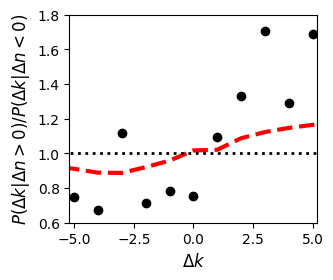

In [20]:
plt.figure(figsize=(3.2, 2.7))
plt.ylabel(r"$P(\Delta k | \Delta n > 0) / P(\Delta k | \Delta n < 0)$", fontsize=12)
plt.xlabel(r"$\Delta k$", fontsize=12)

plt.xlim(-5.2,5.2)
plt.ylim(0.6, 1.8)

y = gp_pos.loc[common_ns].occ.values / gp_neg.loc[common_ns].occ.values
plt.scatter(common_ns, y, c='k')
#plt.plot(common_ns, y, c='k')
y_th = gp_pos_th.loc[common_ns_th].p.values / gp_neg_th.loc[common_ns_th].p.values
plt.plot(common_ns_th, y_th, c='r', ls='--', lw=3)

plt.plot(common_ns, np.ones(len(common_ns)), c='k', ls=':', lw=2)

In [21]:
# statistical test to check if clones with increasing memory conunts also grow more in plasmablasts
from scipy.stats import mannwhitneyu
print(mannwhitneyu(nosparse_data_pos, nosparse_data_neg))

MannwhitneyuResult(statistic=np.float64(785497.0), pvalue=np.float64(3.5585539147640236e-09))
